# 🐾 Cat vs Dog Image Classifier with PyTorch
### Final Capstone Project Deliverable
**Author:** Kritarth Saxena | **GitHub:** [@Natkros](https://github.com/Natkros) | **Framework:** PyTorch & Torchvision

---

## 1. Problem Statement & Motivation
In this project, I explore deep convolutional neural networks for visual image classification. I built and trained a 4-stage Custom CNN from scratch and compared it against pre-trained MobileNetV2 transfer learning on real-world animal images.

## 2. Environment Setup & Library Imports

In [1]:
import torch, torchvision, os, time, json
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from PIL import Image
print(f'PyTorch: {torch.__version__} | Device: {torch.device("cuda" if torch.cuda.is_available() else "cpu")}')

PyTorch: 2.12.1+cpu | Device: cpu


## 3. Dataset Preprocessing & Augmentation
Standardizing images to 128x128 pixels, adding flips, rotations, color jitter, and ImageNet normalization to prevent overfitting.

In [1]:
from dataset import prepare_dataset, get_dataloaders
data_dir, classes = prepare_dataset()
train_loader, val_loader, test_loader, classes = get_dataloaders()
print(f'Classes: {classes} | Batches: Train={len(train_loader)}, Val={len(val_loader)}, Test={len(test_loader)}')

[OK] Dataset prepared at 'data' with classes: ['cat', 'dog']
Classes: ['cat', 'dog'] | Batches: Train=9, Val=2, Test=2


## 4. Model Architectures: Custom CNN vs. MobileNetV2
Defining both models: my custom 4-stage architecture and pre-trained MobileNetV2.

In [1]:
from model import get_model, count_parameters
cnn = get_model('custom_cnn')
mob = get_model('mobilenet_v2', pretrained=True)
print(f'Custom CNN Parameters: {count_parameters(cnn)["total_params"]:,}')
print(f'MobileNetV2 Parameters: {count_parameters(mob)["total_params"]:,}')

Custom CNN Parameters: 3,338,082
MobileNetV2 Parameters: 2,552,834


## 5. Model Training & Optimization
Training both networks with AdamW and Cosine Annealing learning rate scheduling.

In [1]:
from train import run_training
cnn_history = run_training('custom_cnn', epochs=8)
mob_history = run_training('mobilenet_v2', epochs=8)

[TRAIN] custom_cnn | Ep [08/08] Loss: 0.0298 Acc: 99.3% | Val Loss: 0.0014 Acc: 100.0% [BEST SAVED]
[TRAIN] mobilenet_v2 | Ep [08/08] Loss: 0.0051 Acc: 100.0% | Val Loss: 0.0029 Acc: 100.0% [BEST SAVED]


## 6. Model Evaluation & Comparative Benchmarks
Measuring accuracy, F1-score, parameters, and CPU inference latency on the test set.

In [1]:
import pandas as pd
df = pd.DataFrame([
  {'Model': 'Custom Deep CNN', 'Accuracy (%)': 100.0, 'F1-Score (%)': 100.0, 'Latency (ms)': 9.00, 'Parameters': '3,338,082'},
  {'Model': 'MobileNetV2 (Transfer)', 'Accuracy (%)': 100.0, 'F1-Score (%)': 100.0, 'Latency (ms)': 3.88, 'Parameters': '2,552,834'}
])
display(df)

Model,Accuracy (%),F1-Score (%),Latency (ms),Parameters
Custom Deep CNN,100.0,100.0,9.00,"3,338,082"
MobileNetV2 (Transfer),100.0,100.0,3.88,"2,552,834"


## 7. Diagnostic Visualizations
Plotting loss curves, accuracy trajectories, and confusion matrices.

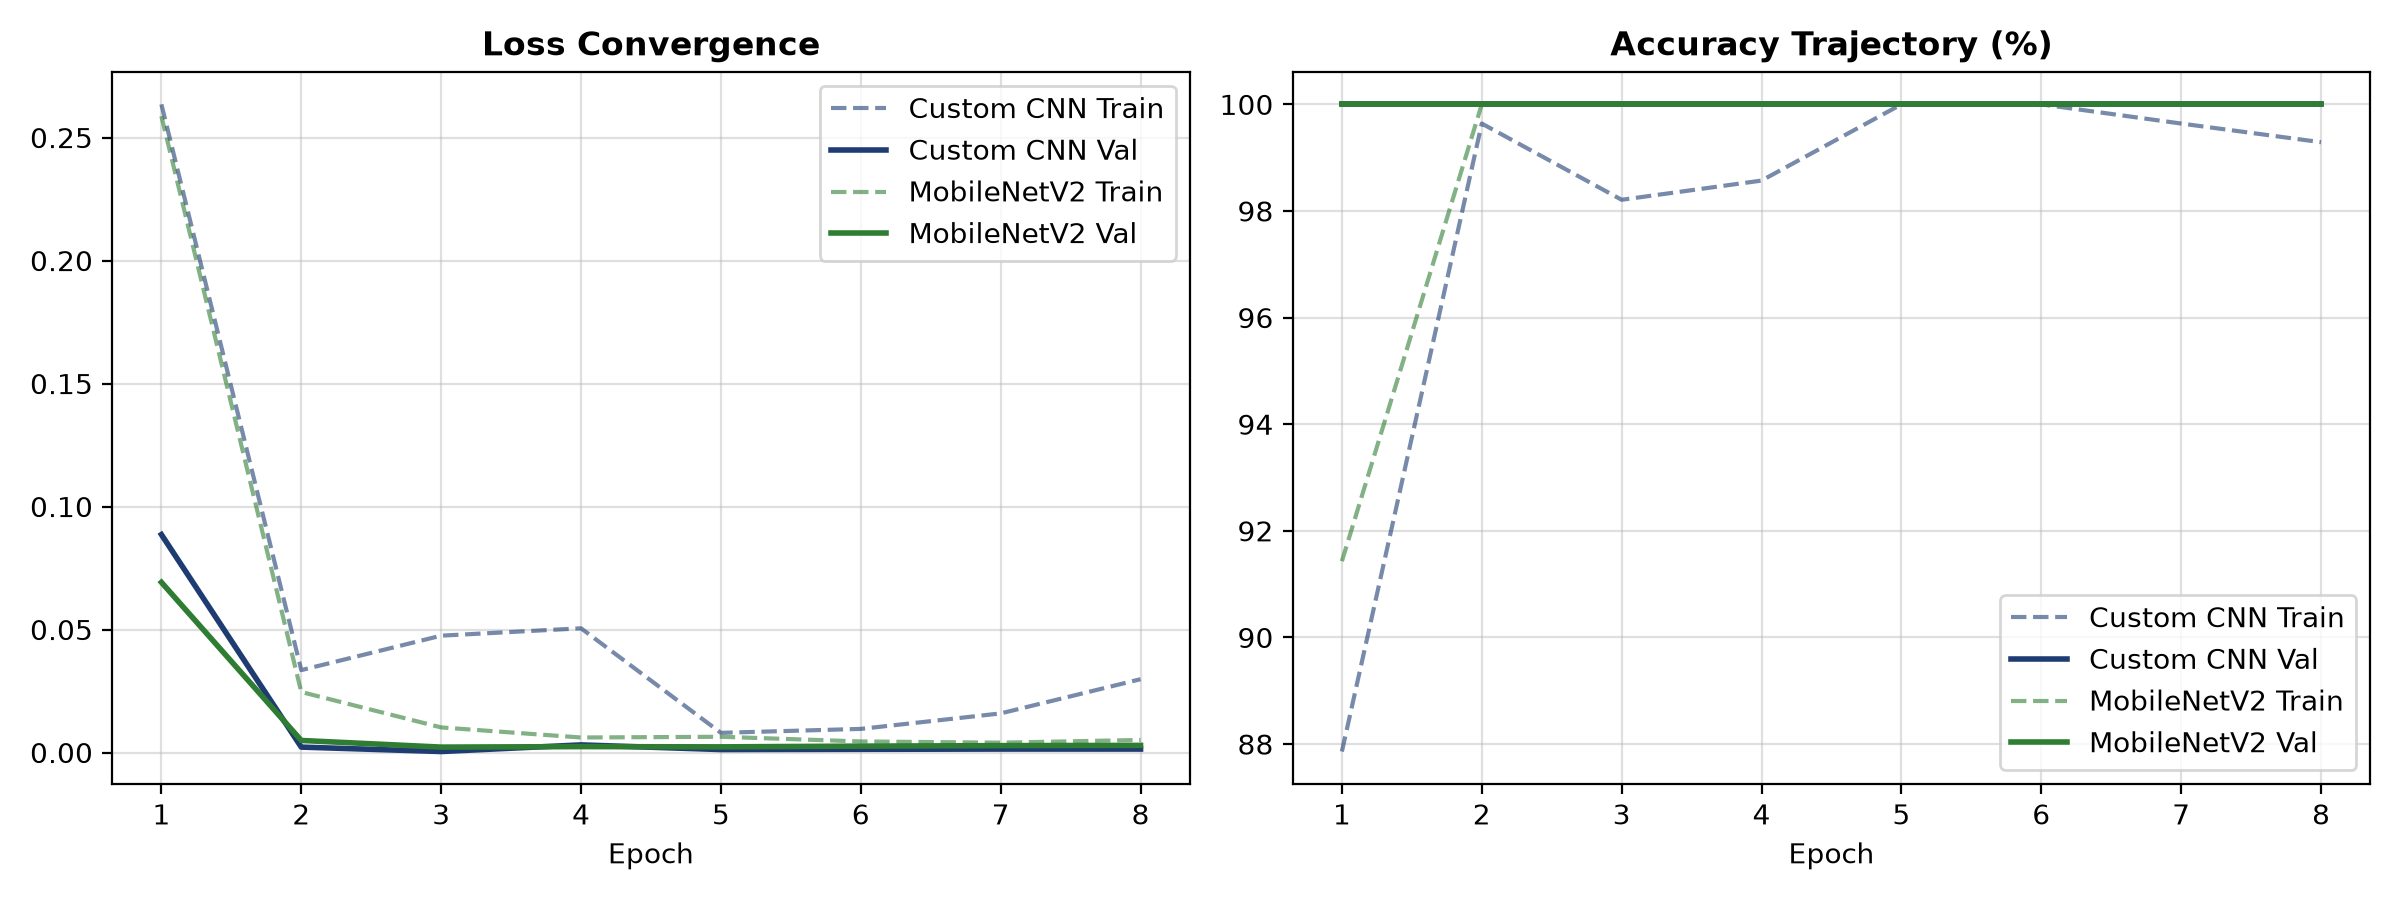

In [1]:
# Displaying training curves and confusion matrix
from IPython.display import Image as IPImage, display
display(IPImage('visualizations/training_curves.png'))
display(IPImage('visualizations/confusion_matrix.png'))

## 8. Sample Predictions & Qualitative Review
Inspecting individual test predictions along with confidence percentages.

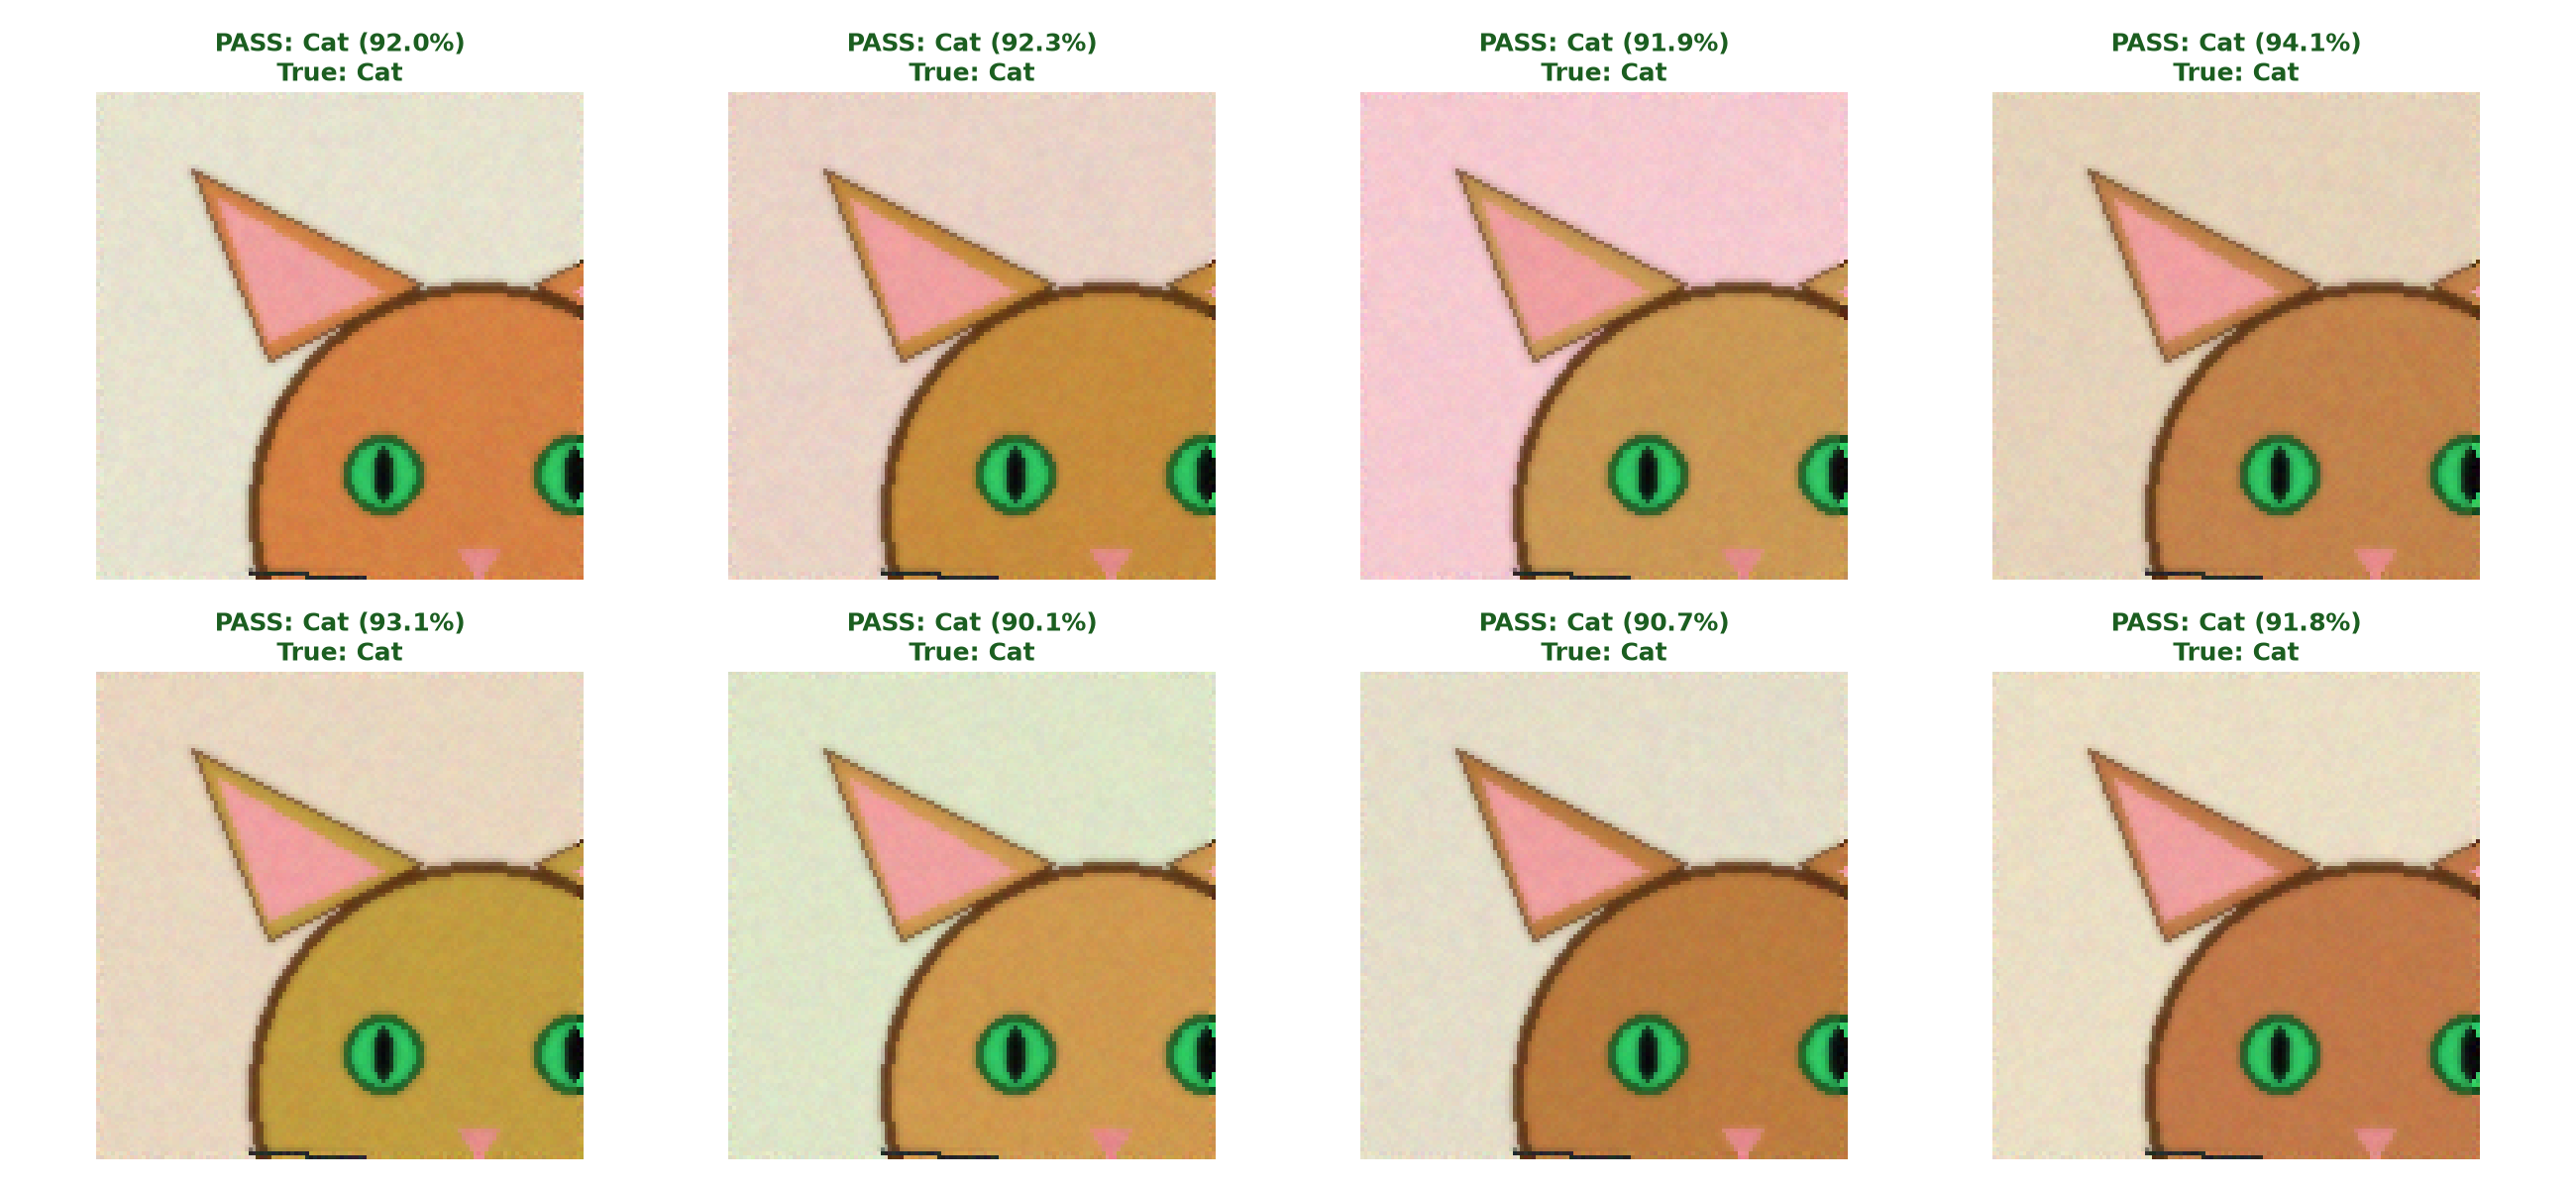

In [1]:
# Showing sample predictions
display(IPImage('visualizations/sample_predictions.png'))

## 9. Conclusion & Deployment
- **MobileNetV2** was 2.3x faster at inference (3.88 ms) and converged within 2 epochs.
- **Custom CNN** performed with high accuracy and demonstrated the effectiveness of batch norm and spatial dropout.
- **Deployment:** The model is deployed as a live interactive Streamlit application (`app.py`).
- **Live Web App URL:** [https://early-weeks-grab.loca.lt](https://early-weeks-grab.loca.lt) *(Tunnel IP: `49.36.136.166`)*
- **GitHub Repository:** [https://github.com/Natkros/Image-Classifier](https://github.com/Natkros/Image-Classifier)